In [1]:
import fastf1
session = fastf1.get_session(2019, 'Monza', 'Q')
session.load(telemetry=False, laps=False, weather=False)
vettel = session.get_driver('VET')
print(f"Pronto {vettel['FirstName']}?")

req         WARNING 	DEFAULT CACHE ENABLED! (24.0 KB) C:\Users\onehi\AppData\Local\Temp\fastf1
core           INFO 	Loading data for Italian Grand Prix - Qualifying [v3.6.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for race_control_messages. Loading data...
_api           INFO 	Fetching race control messages...
req            INFO 	Data has been written to cache!
core           INFO 	Finished loading data for 20 drivers: ['16', '44', '77', '5', '3', '27', '55', '23', '18', '7', '99', '20', '26', '4', '10', '8', '11', '63', '88', '33']


Pronto Sebastian?


Just testing the demos on tutoprial site

core           INFO 	Loading data for Italian Grand Prix - Qualifying [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for timing_app_data. Loading data...
_api           INFO 	Fetching timing app data...
req            INFO 	Data has been written to cache!
core           INFO 	Process

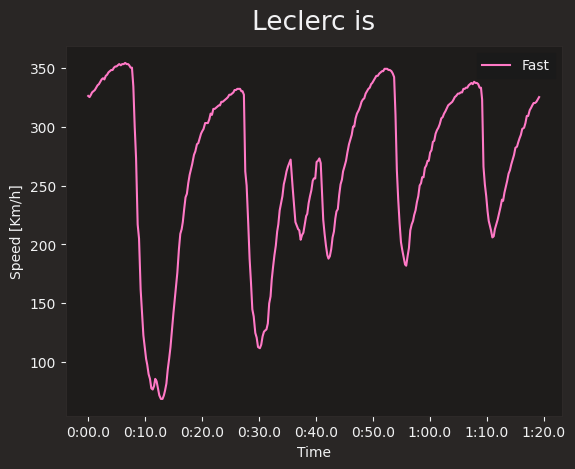

In [2]:
from matplotlib import pyplot as plt
import fastf1
import fastf1.plotting

fastf1.plotting.setup_mpl(color_scheme='fastf1')

session = fastf1.get_session(2019, 'Monza', 'Q')

session.load()
fast_leclerc = session.laps.pick_drivers('LEC').pick_fastest()
lec_car_data = fast_leclerc.get_car_data()
t = lec_car_data['Time']
vCar = lec_car_data['Speed']

# The rest is just plotting
fig, ax = plt.subplots()
ax.plot(t, vCar, label='Fast')
ax.set_xlabel('Time')
ax.set_ylabel('Speed [Km/h]')
ax.set_title('Leclerc is')
ax.legend()
plt.show()

In [3]:
schedule = fastf1.get_event_schedule(2021)

logger      WARNING 	Failed to load schedule from FastF1 backend!
req            INFO 	No cached data found for season_schedule. Loading data...
_api           INFO 	Fetching season schedule...
req            INFO 	Data has been written to cache!


Get all events from 2018 - 2025

In [4]:
import pandas as pd

schedules = []

for year in range(2018, 2025 + 1):
    sch = fastf1.get_event_schedule(year)
    sch['year'] = year
    schedules.append(sch)

all_schedules = pd.concat(schedules, ignore_index=True)

print(all_schedules)

     RoundNumber               Country     Location  \
0              1             Australia    Melbourne   
1              2               Bahrain       Sakhir   
2              3                 China     Shanghai   
3              4            Azerbaijan         Baku   
4              5                 Spain    Barcelona   
..           ...                   ...          ...   
176           20                Mexico  Mexico City   
177           21                Brazil    São Paulo   
178           22         United States    Las Vegas   
179           23                 Qatar       Lusail   
180           24  United Arab Emirates   Yas Island   

                                     OfficialEventName  EventDate  \
0           FORMULA 1 2018 ROLEX AUSTRALIAN GRAND PRIX 2018-03-25   
1           FORMULA 1 2018 GULF AIR BAHRAIN GRAND PRIX 2018-04-08   
2           FORMULA 1 2018 HEINEKEN CHINESE GRAND PRIX 2018-04-15   
3                 FORMULA 1 2018 AZERBAIJAN GRAND PRIX 2018-04-

In [5]:
all_schedules.to_csv("f1_schedule_2018_2025.csv", index=False)

In [7]:
event = fastf1.get_event(2018, 'FORMULA 1 2018 ROLEX AUSTRALIAN GRAND PRIX')
event['EventName']

'Australian Grand Prix'

In [ ]:
all_sessions_data = {}

for idx, event in all_schedules.iterrows():
    year = int(event['EventDate'].year)
    round_number = int(event['RoundNumber'])
    # event_name = event['EventName'] not how get event works


    # session_names = ["FP1", "FP2", "FP3", "Sprint", "SQ", "Qualifying", "Race", "Q", event_name]
    session_names = ["FP1", "FP2", "FP3", "Sprint", "SQ", "Qualifying", "Race", "Q"]

    for sess_name in session_names:
        try:
            session = fastf1.get_session(year, round_number, sess_name)
            session.load() 
            
            all_sessions_data[(year, round_number, sess_name)] = session
            
            print(f"Loaded {sess_name}")

        except Exception as e:

            print(f"Skipping {sess_name}: {e}")

core           INFO 	Loading data for Australian Grand Prix - Practice 1 [v3.6.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            IN

Loaded FP1


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
_api        WARNING 	Driver  5: Encountered 1 timing integrity error(s) near lap(s): [24].
This might be a bug and should be reported.
_api        WARNING 	Driver  7: Encountered 1 timing integrity error(s) near lap(s): [27].


Loaded FP2


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for timing_app_data. Loading data...
_api           INFO 	Fetching timing app data...
req            INFO 	Data has been written to

...

Skipping Race: Failed to load any schedule data.


logger      WARNING 	Failed to load schedule from FastF1 backend!
req            INFO 	No cached data found for season_schedule. Loading data...
_api           INFO 	Fetching season schedule...
logger      WARNING 	Failed to load schedule from F1 API backend!
logger      WARNING 	Failed to load schedule from Ergast API backend!


Skipping Q: Failed to load any schedule data.


logger      WARNING 	Failed to load schedule from FastF1 backend!
req            INFO 	No cached data found for season_schedule. Loading data...
_api           INFO 	Fetching season schedule...
logger      WARNING 	Failed to load schedule from F1 API backend!
logger      WARNING 	Failed to load schedule from Ergast API backend!


Skipping Abu Dhabi Grand Prix: Failed to load any schedule data.


In [13]:
len(all_sessions_data)

261

In [14]:
rows = []

for (year, rnd, sess_name), session in all_sessions_data.items():
    try:
        laps = session.laps.copy()
        laps["Year"] = year
        laps["Round"] = rnd
        laps["Session"] = sess_name
        rows.append(laps)
    except Exception as e:
        print(f"Skipping {year} R{rnd} {sess_name}: {e}")

big_df = pd.concat(rows, ignore_index=True)

big_df.to_csv("all_f1_sessions.csv", index=False)
print("Saved all_f1_sessions.csv")

Skipping 2018 R10 FP1: The data you are trying to access has not been loaded yet. See `Session.load`
Skipping 2018 R10 FP2: The data you are trying to access has not been loaded yet. See `Session.load`
Skipping 2018 R10 FP3: The data you are trying to access has not been loaded yet. See `Session.load`
Skipping 2018 R10 Qualifying: The data you are trying to access has not been loaded yet. See `Session.load`
Skipping 2018 R10 Race: The data you are trying to access has not been loaded yet. See `Session.load`
Skipping 2018 R10 Q: The data you are trying to access has not been loaded yet. See `Session.load`
Skipping 2018 R11 FP1: The data you are trying to access has not been loaded yet. See `Session.load`
Skipping 2018 R11 FP2: The data you are trying to access has not been loaded yet. See `Session.load`
Skipping 2018 R11 FP3: The data you are trying to access has not been loaded yet. See `Session.load`
Skipping 2018 R11 Qualifying: The data you are trying to access has not been loaded y

In [16]:
len(rows)

54

In [17]:
df = pd.read_csv("all_f1_sessions.csv")
print(df.head())

                     Time Driver  DriverNumber                 LapTime  \
0  0 days 00:41:09.160000    VAN             2                     NaN   
1  0 days 01:01:01.904000    VAN             2                     NaN   
2  0 days 01:02:45.996000    VAN             2  0 days 00:01:44.092000   
3  0 days 01:04:15.554000    VAN             2  0 days 00:01:29.558000   
4  0 days 01:21:30.344000    VAN             2                     NaN   

   LapNumber  Stint              PitOutTime               PitInTime  \
0        1.0    1.0  0 days 00:05:01.044000  0 days 00:06:54.173000   
1        2.0    2.0  0 days 00:41:09.160000  0 days 00:42:59.399000   
2        3.0    3.0  0 days 01:01:04.578000                     NaN   
3        4.0    3.0                     NaN                     NaN   
4        5.0    3.0                     NaN  0 days 01:05:46.754000   

              Sector1Time             Sector2Time  ...  \
0  0 days 00:00:50.217000  0 days 00:00:26.276000  ...   
1  0 days 00

In [21]:
df.columns


Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'Year', 'Round', 'Session'],
      dtype='object')

In [23]:

filtered_df = df[df['Session'].isin(['Race', 'Sprint'])]
filtered_df.size

333914